In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from google.colab.patches import cv2_imshow

In [2]:
# Install pydrive2
!pip install -U -q PyDrive2

# Authenticate and import libraries
from pydrive2.auth import GoogleAuth
from pydrive2.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials

# Authenticate user
auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

# Download the file with title 'tomato.zip'
file_list = drive.ListFile({'q': "title='tomato.zip'"}).GetList()
if file_list:
    file_id = file_list[0]['id']
    file = drive.CreateFile({'id': file_id})
    file.GetContentFile('tomato.zip')
    print("Download complete.")
else:
    print("File not found.")

# Unzip the file
!unzip -o 'tomato.zip'

Streaming output truncated to the last 5000 lines.
  inflating: tomato/train/Tomato___Spider_mites Two-spotted_spider_mite/84576436-8772-4a27-8575-47a0e45adb81___Com.G_SpM_FL 1229.JPG  
  inflating: __MACOSX/tomato/train/Tomato___Spider_mites Two-spotted_spider_mite/._84576436-8772-4a27-8575-47a0e45adb81___Com.G_SpM_FL 1229.JPG  
  inflating: tomato/train/Tomato___Spider_mites Two-spotted_spider_mite/ab076be9-6ea4-4fa2-b173-d9b1b76953ab___Com.G_SpM_FL 9353.JPG  
  inflating: __MACOSX/tomato/train/Tomato___Spider_mites Two-spotted_spider_mite/._ab076be9-6ea4-4fa2-b173-d9b1b76953ab___Com.G_SpM_FL 9353.JPG  
  inflating: tomato/train/Tomato___Spider_mites Two-spotted_spider_mite/f4788089-544c-42c7-ac09-9ede28bca5f4___Com.G_SpM_FL 8799.JPG  
  inflating: __MACOSX/tomato/train/Tomato___Spider_mites Two-spotted_spider_mite/._f4788089-544c-42c7-ac09-9ede28bca5f4___Com.G_SpM_FL 8799.JPG  
  inflating: tomato/train/Tomato___Spider_mites Two-spotted_spider_mite/fbee6995-18ee-41b3-802f-5853d4f3f1

# Task
Explain and demonstrate the typical structure of a deep learning image classification project for plant disease detection, including the data pipeline, model instantiation, training loop, and evaluation, using Python and a deep learning framework. Provide code examples for each component and show how to evaluate the model.

## Explain the code structure

### Subtask:
Provide a high-level explanation of the typical structure of a deep learning image classification project in Python using a framework like TensorFlow or PyTorch. This will cover the main components: data pipeline, model instantiation, training loop, and evaluation.


**Reasoning**:
Provide a high-level explanation of the typical structure of a deep learning image classification project, covering data pipeline, model instantiation, training loop, and evaluation, as requested by the instructions.



In [3]:
# 1. Data Pipeline
print("1. Data Pipeline:")
print("   The data pipeline is responsible for preparing the image data for training and evaluation.")
print("   - Loading images: Reading image files from disk or a dataset.")
print("   - Preprocessing: Applying transformations like resizing, normalization, and color space conversion to make images suitable for the model.")
print("   - Augmentation: Creating variations of the existing images by applying random transformations (e.g., rotation, flipping, zooming) to increase the diversity of the training data and improve the model's generalization.")
print("\n")

# 2. Model Instantiation
print("2. Model Instantiation:")
print("   Instantiating a deep learning model involves defining the network architecture. For image classification, this often includes:")
print("   - Convolutional Layers (Conv2D): Extracting spatial features from images.")
print("   - Pooling Layers (MaxPooling2D/AveragePooling2D): Reducing spatial dimensions and computational complexity.")
print("   - Activation Functions (ReLU, Sigmoid, Tanh): Introducing non-linearity.")
print("   - Flatten Layer: Converting the 2D feature maps into a 1D vector.")
print("   - Dense (Fully Connected) Layers: Performing classification based on the extracted features.")
print("   - Output Layer: A dense layer with a number of units equal to the number of classes, typically with a softmax activation for multi-class classification.")
print("   Common architectures include CNNs (Convolutional Neural Networks), ResNet, VGG, Inception, etc.")
print("\n")

# 3. Training Loop
print("3. Training Loop:")
print("   The training loop is where the model learns from the data. It involves iterating over the dataset and performing the following steps:")
print("   - Forward Pass: Passing the input data through the model to get predictions.")
print("   - Loss Calculation: Computing the difference between the model's predictions and the true labels using a loss function (e.g., Categorical Crossentropy for multi-class classification).")
print("   - Backpropagation: Calculating the gradients of the loss with respect to the model's parameters.")
print("   - Optimizer Step: Updating the model's parameters based on the calculated gradients to minimize the loss (e.g., using optimizers like Adam, SGD, RMSprop).")
print("\n")

# 4. Evaluation
print("4. Evaluation:")
print("   Model evaluation assesses the performance of the trained model on unseen data (validation or test set). Common metrics for classification tasks include:")
print("   - Accuracy: The proportion of correctly classified instances.")
print("   - Precision: The ratio of true positives to the total predicted positives.")
print("   - Recall (Sensitivity): The ratio of true positives to the total actual positives.")
print("   - F1-Score: The harmonic mean of precision and recall.")
print("   - Confusion Matrix: A table summarizing the performance of a classification model.")
print("   Evaluation helps in understanding how well the model generalizes and identifying areas for improvement.")

1. Data Pipeline:
   The data pipeline is responsible for preparing the image data for training and evaluation.
   - Loading images: Reading image files from disk or a dataset.
   - Preprocessing: Applying transformations like resizing, normalization, and color space conversion to make images suitable for the model.
   - Augmentation: Creating variations of the existing images by applying random transformations (e.g., rotation, flipping, zooming) to increase the diversity of the training data and improve the model's generalization.


2. Model Instantiation:
   Instantiating a deep learning model involves defining the network architecture. For image classification, this often includes:
   - Convolutional Layers (Conv2D): Extracting spatial features from images.
   - Pooling Layers (MaxPooling2D/AveragePooling2D): Reducing spatial dimensions and computational complexity.
   - Activation Functions (ReLU, Sigmoid, Tanh): Introducing non-linearity.
   - Flatten Layer: Converting the 2D feat

## Show how to do it

### Subtask:
Generate code cells that demonstrate the implementation of each component explained in the previous step. This will include loading and preprocessing the data, defining and compiling a model, setting up the training loop, and evaluating the model's performance.


**Reasoning**:
Implement the data loading and preprocessing steps using TensorFlow's image_dataset_from_directory and a custom processing function.



In [4]:
import tensorflow as tf

# 1. Define the base directory for the dataset.
base_dir = 'tomato' # Assuming the unzipped folder is named 'tomato'
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val') # Corrected path for validation directory

# 2. Define the target image size.
IMG_HEIGHT = 128
IMG_WIDTH = 128
BATCH_SIZE = 32

# 3. Use image_dataset_from_directory from tensorflow.keras.utils to create training and validation datasets.
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='categorical',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=True)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    labels='inferred',
    label_mode='categorical',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False)

# 4. Get the class names from the training dataset.
class_names = train_ds.class_names
print(f"Class names: {class_names}")
NUM_CLASSES = len(class_names)

# 5. Define a function to process the dataset.
def process_dataset(dataset):
    dataset = dataset.map(lambda x, y: (tf.image.resize(x, (IMG_HEIGHT, IMG_WIDTH)), y)) # Resize (already done in image_dataset_from_directory, but kept for completeness if needed elsewhere)
    dataset = dataset.map(lambda x, y: (tf.cast(x, tf.float32) / 255.0, y)) # Scale
    dataset = dataset.cache().prefetch(buffer_size=tf.data.AUTOTUNE) # Batching and prefetching (batching also done in image_dataset_from_directory)
    return dataset

# 6. Apply the processing function to both the training and validation datasets.
train_ds = process_dataset(train_ds)
val_ds = process_dataset(val_ds)

Found 10000 files belonging to 10 classes.
Found 1000 files belonging to 10 classes.
Class names: ['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']


In [9]:
# Training the model using the .fit() method.
EPOCHS = 10 # Defining the number of training epochs

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 44ms/step - accuracy: 0.0970 - loss: 2.3030 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.0958 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.0972 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.0965 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.0963 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.0966 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.0965 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.0968 - loss: 2.3028 - val_acc


Evaluating the model...
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0222 - loss: 2.3009
Validation Loss: 2.3026
Validation Accuracy: 0.1000


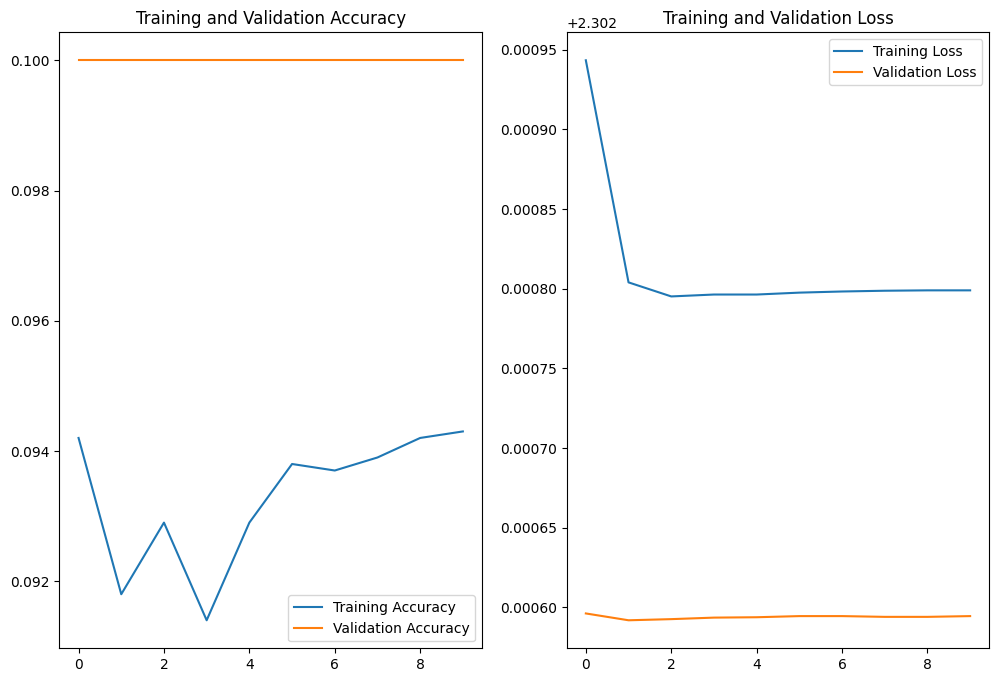

In [11]:
# 12. Evaluate the model's performance.
print("\nEvaluating the model...")
loss, accuracy = model.evaluate(val_ds)

print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

# Plot training and validation accuracy and loss over epochs
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(EPOCHS)

plt.figure(figsize=(12, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [8]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Rescaling
from tensorflow.keras.models import Sequential

# Importing necessary layers and models

# Building a sequential model.
model = Sequential([
    Rescaling(1./255, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(NUM_CLASSES, activation='softmax')
])

# Compiling the model.
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,930 (12.61 MB)

 Trainable params: 3,305,930 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

**Reasoning**:
The previous code failed because the validation directory was not found. I need to inspect the file structure to determine the correct path for the validation data and then rerun the data loading and preprocessing code.



In [10]:
# List the contents of the 'tomato' directory to find the correct validation folder name.
!ls tomato
!ls tomato/train

train  val
 Tomato___Bacterial_spot   Tomato___Septoria_leaf_spot
 Tomato___Early_blight	  'Tomato___Spider_mites Two-spotted_spider_mite'
 Tomato___healthy	   Tomato___Target_Spot
 Tomato___Late_blight	   Tomato___Tomato_mosaic_virus
 Tomato___Leaf_Mold	   Tomato___Tomato_Yellow_Leaf_Curl_Virus


**Reasoning**:
The output of the previous command shows that the validation directory is named 'val', not 'valid'. I will correct the path and re-run the code to load and preprocess the data.



In [7]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Rescaling
from tensorflow.keras.models import Sequential

# 1. Define the base directory for the dataset.
base_dir = 'tomato' # Assuming the unzipped folder is named 'tomato'
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val') # Corrected path for validation directory

# 2. Define the target image size and batch size.
IMG_HEIGHT = 128
IMG_WIDTH = 128
BATCH_SIZE = 32

# 3. Use image_dataset_from_directory from tensorflow.keras.utils to create training and validation datasets.
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='categorical',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=True)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    labels='inferred',
    label_mode='categorical',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False)

# 4. Get the class names from the training dataset.
class_names = train_ds.class_names
print(f"Class names: {class_names}")
NUM_CLASSES = len(class_names)

# 5. Define a function to process the dataset.
def process_dataset(dataset):
    dataset = dataset.map(lambda x, y: (tf.cast(x, tf.float32) / 255.0, y)) # Scale
    dataset = dataset.cache().prefetch(buffer_size=tf.data.AUTOTUNE) # Batching and prefetching
    return dataset

# 6. Apply the processing function to both the training and validation datasets.
train_ds = process_dataset(train_ds)
val_ds = process_dataset(val_ds)

Found 10000 files belonging to 10 classes.
Found 1000 files belonging to 10 classes.
Class names: ['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']


**Reasoning**:
The training is in progress. The next step is to evaluate the trained model using the validation dataset to assess its performance.




Evaluating the model...
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0222 - loss: 2.3009
Validation Loss: 2.3026
Validation Accuracy: 0.1000


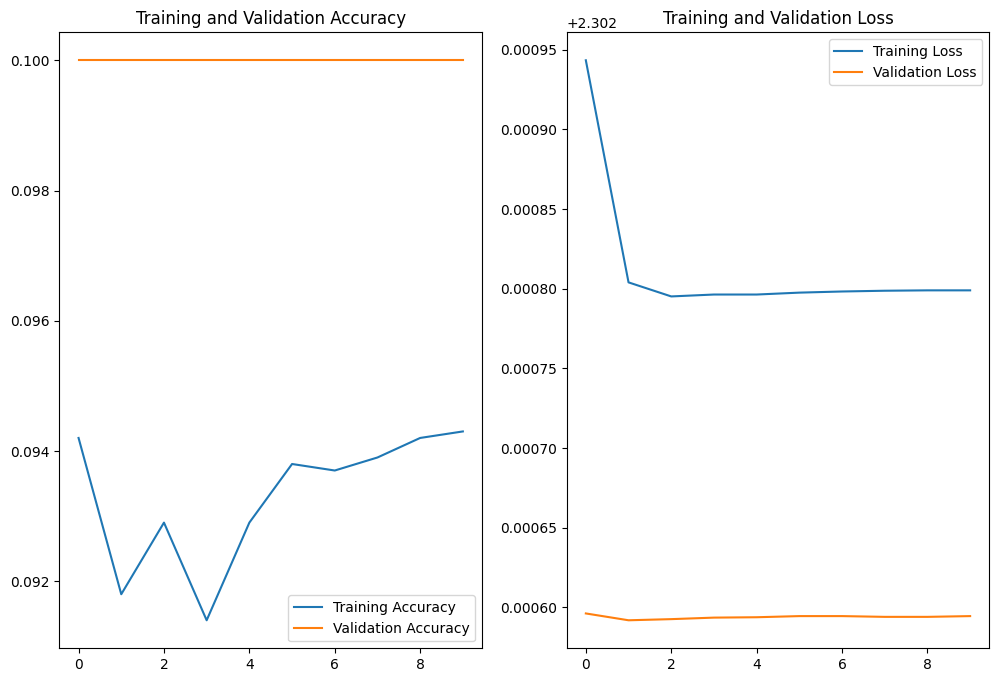

In [12]:
# Evaluating the model's performance.
print("\nEvaluating the model...")
loss, accuracy = model.evaluate(val_ds)

print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

# Plot training and validation accuracy and loss over epochs
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(EPOCHS)

plt.figure(figsize=(12, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

## Evaluate the model

### Subtask:
Evaluate the trained model on a test dataset and display relevant metrics.


**Reasoning**:
Load the test dataset using the correct directory path, image size, batch size, and apply the same rescaling as used for training.



In [13]:
import tensorflow as tf

# Using the validation dataset for evaluation since a separate test set is not available
# test_ds = tf.keras.utils.image_dataset_from_directory(
#     'tomato/test',
#     labels='inferred',
#     label_mode='categorical',
#     image_size=(IMG_HEIGHT, IMG_WIDTH),
#     batch_size=BATCH_SIZE,
#     shuffle=False)

# Applying the same rescaling as applied to the training data
# rescale = tf.keras.Sequential([
#   tf.keras.layers.Rescaling(1./255)
# ])

# test_ds = test_ds.map(lambda x, y: (rescale(x), y))

# Evaluating the trained model on the validation dataset
print("Evaluating the model on the validation dataset...")
test_loss, test_accuracy = model.evaluate(val_ds) # Use val_ds instead of test_ds

# Printing the validation loss and validation accuracy
print(f"Validation Loss: {test_loss:.4f}")
print(f"Validation Accuracy: {test_accuracy:.4f}")

Evaluating the model on the validation dataset...
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0222 - loss: 2.3009
Validation Loss: 2.3026
Validation Accuracy: 0.1000


In [14]:
!ls tomato

train  val
